<a href="https://colab.research.google.com/github/wooihaw/k-youth-2603/blob/main/Lab_3/Lab_3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 3a
#### Build multiple classification models to classify faulty steel plates. The dataset contains information about steel plates and their faults. There are 27 features and the data samples have been classified into 7 different types of steel plate faults.

In [1]:
# Initialization
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Load the required libraries
from pandas import read_csv
from sklearn.model_selection import train_test_split as split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = read_csv("https://raw.githubusercontent.com/wooihaw/datasets/main/steel_faults.csv")

**To do:**
- Print 5 random data samples from the dataset

In [4]:
df.sample(5)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault
504,41,190,2254407,2254463,4995,232,124,527906,39,127,...,0.6422,0.4516,0.0,3.6985,2.1732,1.7482,-0.6242,-0.1743,1.0000,K_Scatch
138,375,386,1063504,1063527,170,18,23,18052,79,127,...,0.6111,1.0000,1.0,2.2304,1.0414,1.3617,0.5217,-0.1704,0.4187,Pastry
1784,1194,1219,172567,172592,204,68,38,25491,114,141,...,0.3677,0.6579,0.5,2.3096,1.3979,1.3979,0.0000,-0.0238,0.8958,Other_Faults
789,305,319,1042404,1042410,32,16,8,4131,120,143,...,0.8750,0.7500,0.0,1.5051,1.1461,0.7782,-0.5714,0.0085,0.1892,Stains
257,37,48,1508012,1508040,178,25,28,18774,92,116,...,0.4400,1.0000,1.0,2.2504,1.0414,1.4472,0.6071,-0.1760,0.5096,Z_Scratch


**To do:**
- Print the descriptive statistics

In [5]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000


In [6]:
df.isna().sum()

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Fault                    0
dtype: int64

To do:


*   Check the class breakdown (number of data samples per class)



In [7]:
df.groupby('Fault').size()

Fault
Bumps           402
Dirtiness        55
K_Scatch        391
Other_Faults    673
Pastry          158
Stains           72
Z_Scratch       190
dtype: int64

**To do:**
- Separate the dataset into features (X) and targets (y)

In [8]:
X = df.drop(columns=['Fault'])
y = df['Fault']

**To do:**  
- Split the dataset to training (75%) and testing (25%) sets

In [9]:
X_train, X_test, y_train, y_test = split(X, y, stratify=y, test_size=0.25, random_state=42)

**To do:**
- Use spotchecking technique to evaluate the performance of kNN, logistic regression, Gaussian naive bayes, support vector machine, decision tree, random forest, gradient boosting trees and MLP classifiers.
- Use stratified k-folds cross-validation with 5 folds.
- Print the mean and standard deviation of the accuracies

In [10]:
models = {}
models['knn'] = KNeighborsClassifier()
models['lgr'] = LogisticRegression()
models['gnb'] = GaussianNB()
models['svc'] = SVC()
models['dtc'] = DecisionTreeClassifier()
models['rfc'] = RandomForestClassifier()
models['gbc'] = GradientBoostingClassifier()
models['mlc'] = MLPClassifier()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in models:
    scores = cross_val_score(models[n], X_train, y_train, cv=skf, n_jobs=-1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')
    

knn: 47.285% +/- 1.182%
lgr: 45.842% +/- 1.621%
gnb: 45.773% +/- 2.178%
svc: 50.653% +/- 0.802%
dtc: 70.447% +/- 1.392%
rfc: 76.701% +/- 1.689%
gbc: 78.213% +/- 0.599%
mlc: 39.313% +/- 8.475%


**To do:**
- Peform feature scaling using standard scaler.
- Use spotchecking technique to evaluate the performance of kNN, logistic regression, Gaussian naive bayes, support vector machine, decision tree, random forest, gradient boosting trees and MLP classifiers on the scaled features.
- Use stratified k-folds cross-validation with 5 folds.
- Print the mean and standard deviation of the accuracies

In [11]:
scl = StandardScaler()
Xs_train = scl.fit_transform(X_train)
Xs_test = scl.transform(X_test)

for n in models:
    scores = cross_val_score(models[n], Xs_train, y_train, cv=skf, n_jobs=-1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')

knn: 72.852% +/- 1.249%
lgr: 71.821% +/- 1.882%
gnb: 59.244% +/- 1.350%
svc: 75.326% +/- 1.924%
dtc: 70.034% +/- 1.448%
rfc: 76.770% +/- 1.664%
gbc: 78.144% +/- 0.673%
mlc: 76.082% +/- 2.632%


**To do:**
- Use Principle Component Analysis (PCA) to reduce the dimensionality of the scaled features to 13.
- Use spotchecking technique to evaluate the performance of kNN, logistic regression, Gaussian naive bayes, support vector machine, decision tree, random forest, gradient boosting trees and MLP classifiers on these features.
- Use stratified k-folds cross-validation with 5 folds.
- Print the mean and standard deviation of the accuracies

In [12]:
pca = PCA(n_components=13)
Xsc_train = pca.fit_transform(Xs_train)
Xsc_test = pca.transform(Xs_test)

for n in models:
    scores = cross_val_score(models[n], Xsc_train, y_train, cv=skf, n_jobs=-1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')

knn: 72.715% +/- 0.740%
lgr: 70.034% +/- 1.973%
gnb: 69.072% +/- 2.118%
svc: 74.914% +/- 1.612%
dtc: 62.749% +/- 2.091%
rfc: 73.952% +/- 1.758%
gbc: 71.340% +/- 1.241%
mlc: 75.258% +/- 1.375%


**To do:**
- Choose the best performing model
- Train the model using the training set and evaluate its performance using the test set

In [13]:
best_model = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)
print(f'Best model accuracy: {best_model.score(X_test, y_test):.3%}')

Best model accuracy: 78.807%


**To do:** Print the classification report

In [14]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Bumps       0.77      0.63      0.70       101
   Dirtiness       0.83      0.71      0.77        14
    K_Scatch       0.95      0.92      0.93        98
Other_Faults       0.70      0.85      0.77       168
      Pastry       0.56      0.51      0.53        39
      Stains       1.00      0.78      0.88        18
   Z_Scratch       0.98      0.90      0.93        48

    accuracy                           0.79       486
   macro avg       0.83      0.76      0.79       486
weighted avg       0.80      0.79      0.79       486



**To do:** Plot the confusion matrix

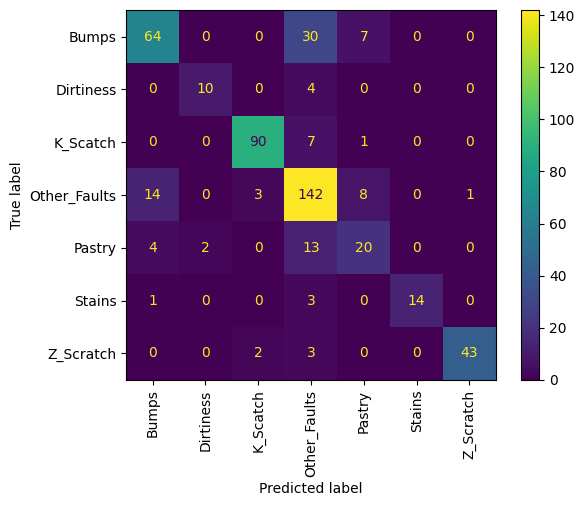

In [16]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.xticks(rotation=90)
plt.show()